<a href="https://colab.research.google.com/github/bhagath-ac07/AI_learning/blob/main/SingleHeadVsMultiHead.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


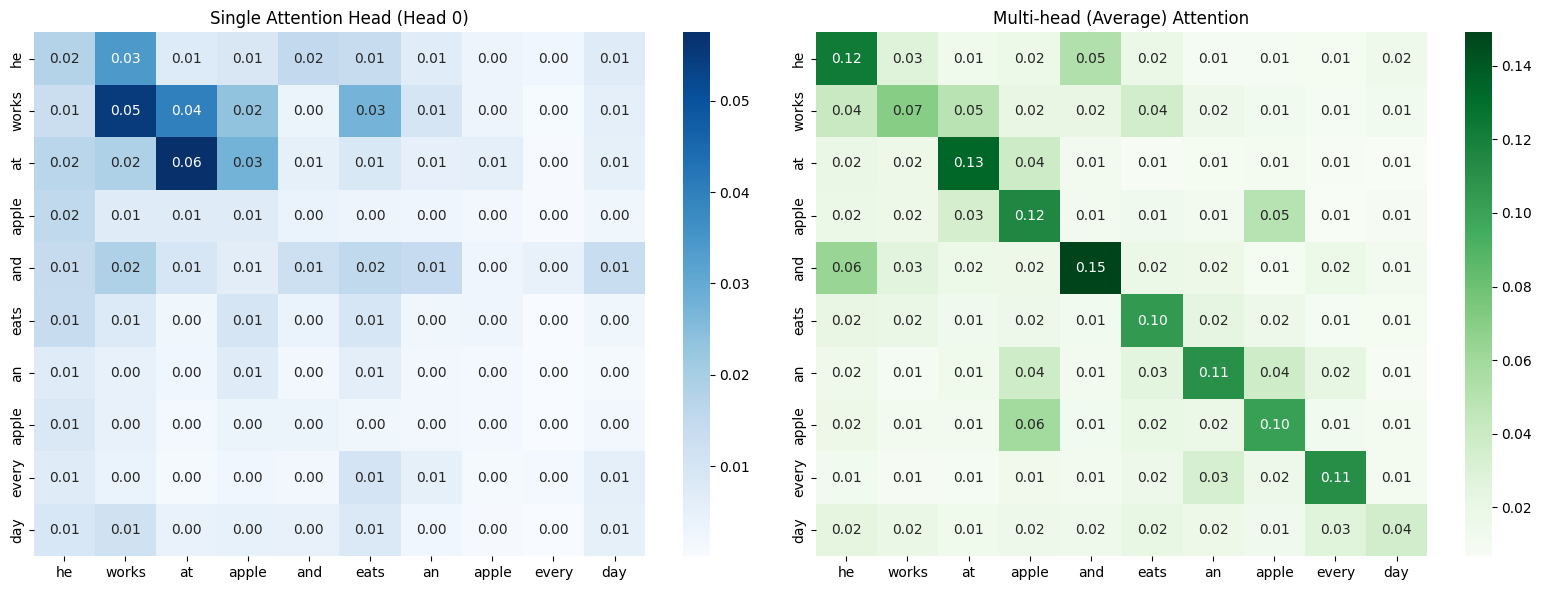

In [ ]:
# Import libraries
from transformers import AutoTokenizer, AutoModel
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Load pre-trained model (this model has 12 attention heads) and tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)

# Input sentence
sentence = "He works at Apple and eats an apple every day"
inputs = tokenizer(sentence, return_tensors="pt")

# Run the model and get attention scores
outputs = model(**inputs)
attentions = outputs.attentions

# Extract the last layer's attention
last_layer_attention = attentions[-1]  # Shape: [1, num_heads, seq_len, seq_len]
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
num_heads = last_layer_attention.shape[1]

# Convert attention and tokens to NumPy arrays
head_0 = last_layer_attention[0, 0].detach().numpy()
avg_attention = last_layer_attention[0].mean(dim=0).detach().
numpy()

# Remove [CLS] and [SEP] tokens
tokens_cleaned = tokens[1:-1]
head_0_cleaned = head_0[1:-1, 1:-1]
avg_attention_cleaned = avg_attention[1:-1, 1:-1]


# Set up side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap for single head (Head 0)
sns.heatmap(head_0_cleaned, xticklabels=tokens_cleaned, yticklabels=tokens_cleaned, cmap="Blues", annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title("Single Attention Head (Head 0)")

# Heatmap for average attention
sns.heatmap(avg_attention_cleaned, xticklabels=tokens_cleaned, yticklabels=tokens_cleaned, cmap="Greens", annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("Multi-head (Average) Attention")

plt.tight_layout()
plt.show()

In [ ]:
!git config --global --unset credential.helper
!rm -f ~/.git-credentials